## Import Lib

In [21]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

## Load Dataset


In [22]:
data = load_diabetes()
X = data.data
y = data.target

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Regression Model

In [24]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mse = mean_squared_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression MSE:", linear_mse)
print("Linear Regression R2:", linear_r2)

Linear Regression MSE: 2900.1936284934804
Linear Regression R2: 0.4526027629719197


## Model with Regularization

### L1 Lasso Regression

In [25]:
lasso_model = Lasso(alpha=0.7)
lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso (L1) MSE:", lasso_mse)
print("Lasso (L1) R2 Score:", lasso_r2)

Lasso (L1) MSE: 3097.856013107508
Lasso (L1) R2 Score: 0.41529496319639037


### L2 Ridge Regression

In [26]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge (L2) MSE:", ridge_mse)
print("Ridge (L2) R2 Score:", ridge_r2)

Ridge (L2) MSE: 3077.41593882723
Ridge (L2) R2 Score: 0.41915292635986545


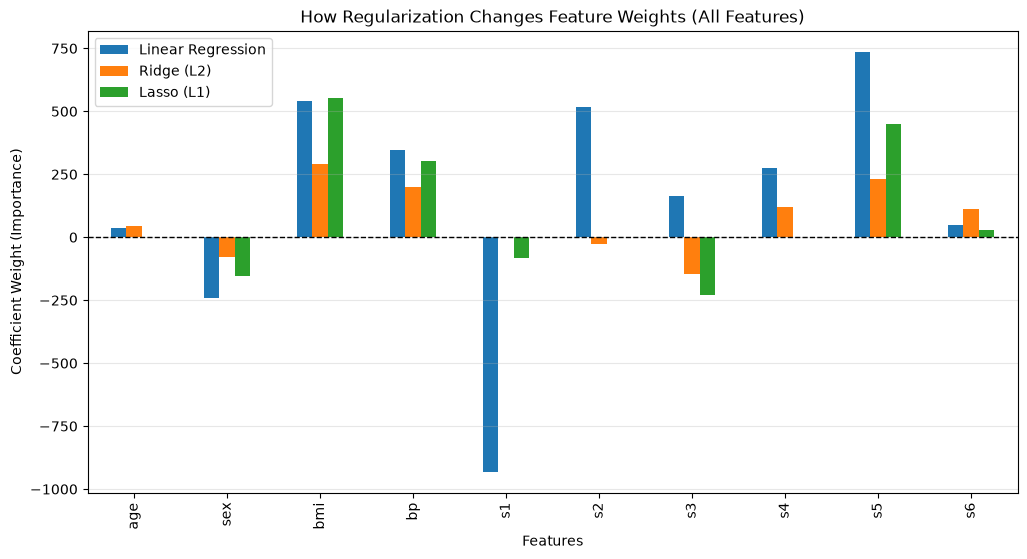

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split

# 1. Load the dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

# 2. USE ALL FEATURES FOR X
X = df.drop(columns=["target"])  # Drops the target, leaving Age, Sex, BMI, BP, etc.
y = df["target"]

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Train models on ALL features
linear_model = LinearRegression().fit(X_train, y_train)
ridge_model = Ridge(alpha=1.0).fit(X_train, y_train)
lasso_model = Lasso(alpha=0.1).fit(X_train, y_train)

# 5. Extract the coefficient weights assigned to each feature
features = X.columns
df_coef = pd.DataFrame(
    {
        "Linear Regression": linear_model.coef_,
        "Ridge (L2)": ridge_model.coef_,
        "Lasso (L1)": lasso_model.coef_,
    },
    index=features,
)

# 6. Plot the coefficients
df_coef.plot(kind="bar", figsize=(12, 6))
plt.title("How Regularization Changes Feature Weights (All Features)")
plt.xlabel("Features")
plt.ylabel("Coefficient Weight (Importance)")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.grid(axis="y", alpha=0.3)
plt.show()


In [28]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import GridSearchCV, train_test_split

# 1. โหลดข้อมูล (ใช้ทุกฟีเจอร์)
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
X = df.drop(columns=["target"])
y = df["target"]

# 2. แบ่งข้อมูลออกเป็น Train และ Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. กำหนดช่วงของค่า alpha ที่เราต้องการให้คอมพิวเตอร์ลองทดสอบ
# ลองตั้งแต่ค่าน้อยมากๆ (0.001) ไปจนถึงค่ามาก (100)
alphas = {"alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]}

# 4. ใช้ GridSearchCV ในการค้นหาค่าที่ดีที่สุด (ทำ Cross-Validation 5 รอบ)
grid_ridge = GridSearchCV(Ridge(), alphas, cv=5, scoring="r2")
grid_lasso = GridSearchCV(Lasso(), alphas, cv=5, scoring="r2")

grid_ridge.fit(X_train, y_train)
grid_lasso.fit(X_train, y_train)

# 5. เทรนโมเดล Linear Regression แบบธรรมดาเพื่อเป็นตัวเปรียบเทียบ
linear_model = LinearRegression().fit(X_train, y_train)

# 6. แสดงผลลัพธ์ที่ได้จากการจูน
print("=== ผลการค้นหา Alpha ที่ดีที่สุด ===")
print(f"ค่า Alpha ที่ดีที่สุดของ Ridge: {grid_ridge.best_params_['alpha']}")
print(f"ค่า Alpha ที่ดีที่สุดของ Lasso: {grid_lasso.best_params_['alpha']}")
print("\n=== เปรียบเทียบ R² Score บนข้อมูลทดสอบ (Test Set) ===")
print(f"Linear Regression R² : {linear_model.score(X_test, y_test):.4f}")
print(f"Tuned Ridge R²       : {grid_ridge.score(X_test, y_test):.4f}")
print(f"Tuned Lasso R²       : {grid_lasso.score(X_test, y_test):.4f}")


=== ผลการค้นหา Alpha ที่ดีที่สุด ===
ค่า Alpha ที่ดีที่สุดของ Ridge: 0.1
ค่า Alpha ที่ดีที่สุดของ Lasso: 0.1

=== เปรียบเทียบ R² Score บนข้อมูลทดสอบ (Test Set) ===
Linear Regression R² : 0.4526
Tuned Ridge R²       : 0.4609
Tuned Lasso R²       : 0.4719
